# 21 - Demand-Weighted Criticality

My centrality rankings so far are purely topological: a station scores highly because of its position in the graph. They do not say how many people live near that station or might be affected by its loss. In this notebook I add a population-based weight and check how much the critical-station ranking changes.

## Important interpretation

**The GTFS feed has no ridership data.** I do not have boardings, alightings, fare validations, vehicle loads, or an origin-destination matrix. Every demand value below is therefore a **proxy** built from the data I do have:

1. residential population by 2021 CBS statistical area, joined to stops in notebook 09; and
2. scheduled service volume (`stop_use_count`), used as a mild multiplier.

I keep the word `proxy` in the figure titles and output column names, including `demand_weighted_betweenness_proxy`. These values are not estimated passenger counts; they measure population exposure under a set of assumptions that I list near the end.

## The research question

My question is: if shortest-path pairs receive more weight when more residents live near their endpoints, which stations gain or lose rank compared with notebook 04? I especially want to see whether dense residential areas promote stations that are not remarkable in the unweighted topology.

## The methodology in one paragraph

I first divide each statistical area's population among its stops, then smooth those shares across nearby stops with a distance-decay gravity kernel while preserving the total population. This gives `population_served`. I combine it with a softened service term to get `demand_weight`. I then estimate demand-weighted betweenness with a Brandes-style algorithm: sources are sampled in proportion to their demand weight and destinations contribute their own weight during dependency accumulation. I compare the result with notebook 04's approximate betweenness and with a uniform-weight control from the same estimator. The control helps separate the effect of endpoint weighting from differences between implementations or samples.

## Required inputs

* `outputs/nb/02_graph_construction/tables/nodes.csv`, `edges.csv` - the trip-adjacency graph (notebook **02**).
* `outputs/nb/04_centrality_analysis/tables/stop_metrics.csv` - the topological baseline, specifically the column `approx_betweenness` (notebook **04**).
* `outputs/nb/09_socioeconomic_equity/tables/stops_with_socioeconomic.csv` and `socioeconomic_neighborhood_access.csv` - the join to CBS statistical areas, the population, and the socioeconomic cluster (notebook **09**).

I do not read the raw 816 MB `stop_times.txt` here. The graph and service counts already come from stage 02, while the population join comes from stage 09.

## Outputs under `outputs/nb/21_demand_weighted_criticality/`

* `tables/demand_proxy.csv` - `stop_id, population_served, demand_weight` (the contract file).
* `tables/demand_weighted_criticality.csv` - `stop_id, stop_name, topological_rank, demand_weighted_rank, rank_shift` (the contract file).
* `demand_summary.json` - the main summary values, the parameters, and the agreement statistics.
* `tables/demand_proxy_detail.csv` - the proxy with all its intermediate columns and the CBS join quality per stop.
* `tables/criticality_lens_detail.csv` - the three score columns and three rank columns per stop.
* `tables/rank_agreement.csv` - Spearman rho and top-N overlap between the lenses.
* `tables/rank_movers.csv` - the biggest gainers and losers in the ranking.
* `tables/rank_shift_by_socioeconomic_cluster.csv` - mean rank shift per CBS cluster 1-10.
* `tables/proxy_sensitivity.csv`, `tables/betweenness_sensitivity.csv` - how much the proxy parameters matter.
* `figures/*.png`.

I leave every input file unchanged.

## 1. Initialize the working environment

I start by setting up the same local/Colab environment used in the other notebooks. `_ensure(...)` installs only missing packages, and `find_repo_root()` locates the data folder or clones the repository in Colab. The cell defines `REPO`, `DATA`, and `OUT` for the rest of the notebook.

In [ ]:
# --- Environment bootstrap (safe to re-run, works locally and on Google Colab) ---
import os, sys, subprocess
from pathlib import Path

print(f"Python {sys.version.split()[0]} -> {sys.executable}")

def _ensure(*pkgs):
    """Install only the packages that are actually missing."""
    import importlib.util
    alias = {"scikit-learn": "sklearn", "python-louvain": "community",
             "python-bidi": "bidi", "node2vec": "node2vec"}
    missing = [p for p in pkgs
               if importlib.util.find_spec(alias.get(p, p.replace("-", "_"))) is None]
    if missing:
        print("Installing missing packages:", ", ".join(missing))
        print("Using interpreter:", sys.executable)
        subprocess.run([sys.executable, "-m", "pip", "install",
                        "--disable-pip-version-check", *missing],
                       check=True, timeout=900)

def find_repo_root():
    """Find the repo locally; on Colab, clone it."""
    here = Path(os.getcwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "israel-public-transportation").is_dir():
            return cand
    target = Path("/content/israel-transit-network-resilience")
    if not target.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/seanfourman/israel-transit-network-resilience.git",
                        str(target)], check=True)
    return target

REPO = find_repo_root()
os.chdir(REPO)
DATA = REPO / "israel-public-transportation"
OUT = REPO / "outputs" / "nb"
OUT.mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO)

## 2. Libraries, stage folders, and tunable constants

I import the graph, table, spatial, and plotting packages and create this stage's `tables/` and `figures/` folders under `outputs/nb/21_demand_weighted_criticality/`.

I keep the modeling choices and runtime controls together:

* `CATCHMENT_RADIUS_M = 500` defines the maximum distance over which I share population between stops.
* `DECAY_LENGTH_M = 250` controls the kernel `exp(-d / DECAY_LENGTH_M)`, so influence falls to `1/e` after 250 meters.
* `SERVICE_EXPONENT = 0.5` controls how strongly scheduled visits affect the weight. Zero means population only and one makes the service term fully proportional.
* `K_DEMAND_SOURCES = 400` is the main accuracy/runtime control. Each source requires a breadth-first search and dependency accumulation over the largest component, and I run both a uniform and demand-weighted lens. Lower values run faster but produce noisier rankings.
* `RUN_WEIGHT_SENSITIVITY` and `RUN_BETWEENNESS_SENSITIVITY` control the parameter checks. Rebuilding weights is cheap; rerunning betweenness for alternative proxies adds several minutes.

I implement the estimator below because NetworkX's standard function can weight path lengths but cannot apply separate weights to origin and destination nodes.

In [2]:
# --- Libraries, stage folders and every tunable constant -------------------
_ensure('pandas', 'numpy', 'networkx', 'matplotlib', 'seaborn', 'scipy')

import json
import math
import time
from collections import deque

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.05)

STAGE = OUT / '21_demand_weighted_criticality'
TABLES = STAGE / 'tables'
FIGURES = STAGE / 'figures'
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

# --- Demand PROXY parameters ----------------------------------------------
CATCHMENT_RADIUS_M = 500.0    # walking catchment of a stop, metres
DECAY_LENGTH_M = 250.0        # gravity kernel exp(-d / DECAY_LENGTH_M)
SERVICE_EXPONENT = 0.5        # 0 = population only, 1 = fully service-proportional

# --- Betweenness estimator cost -------------------------------------------
K_DEMAND_SOURCES = 400        # sampled sources per lens (main cost knob)
SEED_DEMAND = 21              # seed of the demand-weighted lens
SEED_UNIFORM = 22             # seed of the uniform-weight control lens
PROGRESS_EVERY = 50           # print a progress line every N sampled sources

# --- Sensitivity blocks ----------------------------------------------------
RUN_WEIGHT_SENSITIVITY = True        # cheap: re-computes the proxy only
RUN_BETWEENNESS_SENSITIVITY = True   # costly: two extra estimator runs
SENSITIVITY_K = 150                  # sources used inside the sensitivity runs
RADIUS_GRID = [300.0, 500.0, 1000.0]
SERVICE_EXPONENT_GRID = [0.0, 0.5, 1.0]

# --- Display settings ------------------------------------------------------
TOP_N = 15                    # rows in the top-N tables / bars in the charts
MOVERS_N = 25                 # gainers and losers written to rank_movers.csv
OVERLAP_SIZES = [50, 200, 1000]
FIG_DPI = 150

print('stage folder :', STAGE)
print('networkx', nx.__version__, '| pandas', pd.__version__, '| numpy', np.__version__)

stage folder : C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\21_demand_weighted_criticality
networkx 3.4.2 | pandas 2.3.3 | numpy 1.26.4


## 3. Rendering Hebrew labels

Several plots name the stations that move in the ranking, so I need readable Hebrew labels. I select fonts with Hebrew glyphs and keep `fix_he()` compatible with this Matplotlib build, which already performs the bidirectional layout. I also remove any stale text patch left by a previous cell run.

In [3]:
# Stop names are Hebrew. This matplotlib build applies the Unicode bidi algorithm itself,
# so Hebrew renders correctly when the raw (logical-order) string is passed to matplotlib.
# I do not pre-reorder it with python-bidi because that would reverse it a second time.
# fix_he is a no-op here, and I only select a Hebrew-capable font. (If Hebrew renders
# reversed on some other matplotlib build that has no native bidi, that build would need
# get_display; this one does not.)
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.text as mtext

def fix_he(text):
    """No-op: matplotlib reorders Hebrew itself on this build; pre-reordering would reverse it."""
    return text

def install_hebrew():
    # Arial exists on Windows; DejaVu Sans ships with matplotlib and covers Hebrew.
    matplotlib.rcParams["font.family"] = ["Arial", "DejaVu Sans"]
    matplotlib.rcParams["axes.unicode_minus"] = False
    # Write axis numbers as plain decimals - never scientific notation (no "1e-4") and no
    # "+1e-4"-style offset labels, so small values like betweenness read literally.
    matplotlib.rcParams["axes.formatter.useoffset"] = False
    matplotlib.rcParams["axes.formatter.limits"] = (-7, 7)
    # If an earlier run left a bidi patch on Text.set_text, remove it so labels render raw.
    if hasattr(mtext.Text, "_orig_set_text"):
        mtext.Text.set_text = mtext.Text._orig_set_text

install_hebrew()

## 4. Locating the input stages

I need tables from stages 02, 04, and 09. `stage_dir` finds each folder by its numeric prefix, and `load_stage_table` searches inside it for the named CSV. This avoids duplicating full output paths throughout the notebook.

If a required table is missing, the helpers stop with the stage and filename I need rather than allowing a later merge to fail in a less obvious way.

In [4]:
# --- Resolve earlier stages by two-digit prefix ----------------------------
def stage_dir(prefix, notebook_hint):
    """Return the stage folder whose name starts with `prefix`, else raise."""
    matches = sorted(p for p in OUT.glob(prefix + '*') if p.is_dir())
    if not matches:
        raise FileNotFoundError(
            f'No stage folder starting with "{prefix}" under {OUT} - '
            f'run notebook {notebook_hint} first.'
        )
    return matches[0]


def load_stage_table(prefix, filename, notebook_hint, **read_kwargs):
    """Load a CSV written by an earlier stage, with an actionable error message."""
    folder = stage_dir(prefix, notebook_hint)
    candidates = [folder / 'tables' / filename, folder / filename]
    path = next((c for c in candidates if c.exists()), None)
    if path is None:
        found = sorted(folder.rglob(filename))
        path = found[0] if found else None
    if path is None:
        raise FileNotFoundError(
            f'"{filename}" not found anywhere under {folder} - '
            f'run notebook {notebook_hint} first; it is the notebook that writes it.'
        )
    frame = pd.read_csv(path, encoding='utf-8-sig', **read_kwargs)
    print(f'{filename:<42} {len(frame):>7,} rows  <-  {path}')
    return frame


def require_columns(frame, columns, filename):
    """Fail loudly if an upstream contract column is missing."""
    missing = [c for c in columns if c not in frame.columns]
    if missing:
        raise KeyError(
            f'{filename} is missing the column(s) {missing}. '
            f'It has {list(frame.columns)}. Re-run the notebook that produces it.'
        )


print('helpers ready')

helpers ready


## 5. Loading the input

I read five tables:

* `nodes.csv` and `edges.csv` provide the trip-adjacency graph and `stop_use_count`, my service-volume term.
* `stop_metrics.csv` provides the `approx_betweenness` baseline. That column is also sampled, so comparisons with it contain sampling variation from both runs.
* `stops_with_socioeconomic.csv` provides each stop's CBS unit, population, cluster, and the method and distance used for the spatial match.
* `socioeconomic_neighborhood_access.csv` provides one row per area, which I use to fill missing area population and cross-check stop counts.

I check the required columns immediately, before any joins or ranking calculations.

In [5]:
# --- Load the artifacts of notebooks 02, 04 and 09 -------------------------
nodes_df = load_stage_table('02', 'nodes.csv', '02_graph_construction',
                            dtype={'stop_id': str})
edges_df = load_stage_table('02', 'edges.csv', '02_graph_construction',
                            dtype={'from_stop': str, 'to_stop': str})
metrics_df = load_stage_table('04', 'stop_metrics.csv', '04_centrality_analysis',
                              dtype={'stop_id': str})
socio_df = load_stage_table('09', 'stops_with_socioeconomic.csv',
                            '09_socioeconomic_equity', dtype={'stop_id': str})
access_df = load_stage_table('09', 'socioeconomic_neighborhood_access.csv',
                             '09_socioeconomic_equity')

require_columns(nodes_df, ['stop_id', 'stop_name', 'lat', 'lon', 'region', 'stop_use_count'],
                'nodes.csv')
require_columns(edges_df, ['from_stop', 'to_stop', 'trip_frequency'], 'edges.csv')
require_columns(metrics_df, ['stop_id', 'approx_betweenness'], 'stop_metrics.csv')
require_columns(socio_df, ['stop_id', 'socio_unit_id', 'socio_population', 'socio_cluster'],
                'stops_with_socioeconomic.csv')
require_columns(access_df, ['socio_unit_id', 'population', 'stops'],
                'socioeconomic_neighborhood_access.csv')

nodes_df['stop_id'] = nodes_df['stop_id'].astype(str)
metrics_df['stop_id'] = metrics_df['stop_id'].astype(str)
socio_df['stop_id'] = socio_df['stop_id'].astype(str)

print()
print(f'stops in the graph          : {nodes_df["stop_id"].nunique():,}')
print(f'stops with a CBS join       : {socio_df["socio_unit_id"].notna().sum():,}')
print(f'CBS statistical areas        : {access_df["socio_unit_id"].nunique():,}')
print(f'stops covered by stage 04    : {metrics_df["stop_id"].nunique():,}')

nodes.csv                                   30,463 rows  <-  C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\02_graph_construction\tables\nodes.csv
edges.csv                                   51,999 rows  <-  C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\02_graph_construction\tables\edges.csv
stop_metrics.csv                            30,463 rows  <-  C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\04_centrality_analysis\tables\stop_metrics.csv
stops_with_socioeconomic.csv                30,463 rows  <-  C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\09_socioeconomic_equity\tables\stops_with_socioeconomic.csv


socioeconomic_neighborhood_access.csv        2,681 rows  <-  C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\09_socioeconomic_equity\tables\socioeconomic_neighborhood_access.csv

stops in the graph          : 30,463
stops with a CBS join       : 30,060
CBS statistical areas        : 2,681
stops covered by stage 04    : 30,463


## 6. Rebuilding the undirected graph and its largest component

I rebuild the undirected projection `G`, combining the frequencies of both directions for each stop pair, and use its largest connected component `Gc` for shortest-path centrality. Stops outside `Gc` cannot lie on a path between nodes inside it, so I assign them a score of zero rather than treating them as missing.

I count distance in hops, matching notebook 04. Keeping the path definition fixed means the comparison changes only the endpoint weights. Travel-time paths are useful for a separate question, but mixing both changes here would make it difficult to identify what caused a rank shift.

In [6]:
# --- Undirected projection and largest connected component -----------------
def build_undirected_graph(nodes_frame, edges_frame):
    """One edge per unordered station pair; weights of both directions summed."""
    graph = nx.Graph()
    graph.add_nodes_from(nodes_frame['stop_id'].astype(str))
    freq = pd.to_numeric(edges_frame['trip_frequency'], errors='coerce').fillna(1.0)
    for u, v, w in zip(edges_frame['from_stop'].astype(str),
                       edges_frame['to_stop'].astype(str),
                       freq.astype(float)):
        if u == v:
            continue
        if graph.has_edge(u, v):
            graph[u][v]['weight'] += w
        else:
            graph.add_edge(u, v, weight=w)
    return graph


G = build_undirected_graph(nodes_df, edges_df)
components = sorted(nx.connected_components(G), key=len, reverse=True)
Gc = G.subgraph(components[0]).copy()
LCC_NODES = set(Gc.nodes)

print(f'undirected graph      : {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges')
print(f'connected components  : {len(components):,}')
print(f'largest component     : {Gc.number_of_nodes():,} nodes '
      f'({Gc.number_of_nodes() / G.number_of_nodes():.1%}), {Gc.number_of_edges():,} edges')
print(f'outside the LCC       : {G.number_of_nodes() - Gc.number_of_nodes():,} stations '
      f'(scored 0 in every lens)')

undirected graph      : 30,463 nodes, 51,772 edges
connected components  : 12
largest component     : 30,237 nodes (99.3%), 51,523 edges
outside the LCC       : 226 stations (scored 0 in every lens)


## 7. Proxy step 1: splitting each statistical area's population among its stops

CBS population is attached to statistical areas rather than stops. I begin with a simple allocation: divide each area's residents equally among the stops joined to that area. For example, 6,000 residents and 20 matched stops gives a base share of 300 per stop.

This assumes residents and stop use are uniform inside the area. It also divides the same local population among many nearby platforms in stop-dense areas. I accept that as a transparent starting point, then smooth it spatially in the next cell.

I keep two join-quality issues visible:

* Some stops were matched to the nearest polygon rather than contained inside one. I keep `socio_join_method` and `socio_join_distance_m` so distant fallbacks can be identified.
* Stops without a CBS unit or a usable population value receive a base share of zero. I count them explicitly because they cannot act as weighted origins or destinations.

When the stop-level population is missing, I use the matching value from `socioeconomic_neighborhood_access.csv` before assigning zero.

In [7]:
# --- Step 1: population of a statistical area, split across its stops ------
socio = socio_df.drop_duplicates(subset='stop_id').copy()

unit_pop_from_stops = (socio.dropna(subset=['socio_unit_id'])
                            .groupby('socio_unit_id')['socio_population'].first())
unit_pop_from_access = (access_df.dropna(subset=['socio_unit_id'])
                                 .drop_duplicates(subset='socio_unit_id')
                                 .set_index('socio_unit_id')['population'])
unit_population = unit_pop_from_stops.combine_first(unit_pop_from_access)

stops_per_unit = (socio.dropna(subset=['socio_unit_id'])
                       .groupby('socio_unit_id')['stop_id'].nunique())

join_cols = ['stop_id', 'socio_unit_id', 'socio_cluster',
             'socio_join_method', 'socio_join_distance_m']
join_cols = [c for c in join_cols if c in socio.columns]

proxy = (nodes_df[['stop_id', 'stop_name', 'lat', 'lon', 'region', 'metro', 'stop_use_count']]
         .drop_duplicates(subset='stop_id')
         .merge(socio[join_cols], on='stop_id', how='left'))

proxy['unit_population'] = proxy['socio_unit_id'].map(unit_population)
proxy['unit_stops'] = proxy['socio_unit_id'].map(stops_per_unit)
proxy['area_population_share'] = (
    proxy['unit_population'] / proxy['unit_stops'].replace(0, np.nan)
).fillna(0.0)

national_population = float(unit_population.dropna().sum())
allocated = float(proxy['area_population_share'].sum())
no_unit = int(proxy['socio_unit_id'].isna().sum())
no_population = int((proxy['socio_unit_id'].notna() & proxy['unit_population'].isna()).sum())

print(f'CBS population across all areas   : {national_population:,.0f}')
print(f'population allocated to stops     : {allocated:,.0f} '
      f'({allocated / national_population:.1%} of it)')
print(f'stops with no CBS unit            : {no_unit:,}')
print(f'stops whose unit has no population: {no_population:,}')
if 'socio_join_method' in proxy.columns:
    print('\njoin method used per stop:')
    print(proxy['socio_join_method'].value_counts(dropna=False).to_string())
if 'socio_join_distance_m' in proxy.columns:
    far = int((proxy['socio_join_distance_m'] > 1000).sum())
    print(f'\nstops joined to an area more than 1 km away: {far:,} '
          f'(their population attribution is weak)')
proxy[['stop_id', 'stop_name', 'socio_unit_id', 'unit_population',
       'unit_stops', 'area_population_share']].head()

CBS population across all areas   : 8,708,714
population allocated to stops     : 8,708,714 (100.0% of it)
stops with no CBS unit            : 403
stops whose unit has no population: 700

join method used per stop:
socio_join_method
within     23592
nearest     6468
NaN          403

stops joined to an area more than 1 km away: 2,072 (their population attribution is weak)


,stop_id,stop_name,socio_unit_id,unit_population,unit_stops,area_population_share
0,38725,ת. רכבת יבנה מערב,26600001.0,631.0,35.0,18.028571
1,15582,שד. הסנהדרין/שד. ירושלים,26600001.0,631.0,35.0,18.028571
2,15746,שד. ירושלים/שד. הסנהדרין,26600001.0,631.0,35.0,18.028571
3,15725,בית ספר אורמת/נחל חריף,26600001.0,631.0,35.0,18.028571
4,15416,מחלף בית רבן למזרח,8480001.0,1038.0,4.0,259.500000


## 8. Proxy step 2: a gravity kernel over walking distance

Administrative boundaries can separate a stop from nearby residents, so I smooth the base shares with a distance-decay gravity model.

Each source stop `j` redistributes its base share `p_j` across stops within `CATCHMENT_RADIUS_M`, including itself, in proportion to `exp(-d / DECAY_LENGTH_M)`. I normalize the weights separately for each source:

```
population_served[i] = sum_j p_j * exp(-d_ij / L) / sum_{k in radius(j)} exp(-d_jk / L)
```

This preserves the national total rather than counting the same resident once for every nearby stop. A lone stop keeps most of its area's share, while closely spaced stops exchange parts of their shares according to distance.

I use an equirectangular distance approximation around the feed's mean latitude and a spatial grid with cells the size of the catchment radius. That limits each search to nearby cells. Stops without coordinates keep their base share but do not exchange population with neighbors.

In [8]:
# --- Step 2: distance-decayed re-allocation (population-conserving) --------
def allocate_population(lat, lon, base_pop, radius_m, decay_m):
    """Spread each stop's base population over stops within `radius_m`.

    Weights are exp(-d / decay_m), normalised per source, so the sum of the
    returned array equals the sum of `base_pop` (no double counting).
    """
    lat = np.asarray(lat, dtype=float)
    lon = np.asarray(lon, dtype=float)
    base_pop = np.asarray(base_pop, dtype=float)
    n = len(lat)
    served = np.zeros(n, dtype=float)

    valid = np.isfinite(lat) & np.isfinite(lon)
    m_per_deg_lat = 110574.0
    m_per_deg_lon = 111320.0 * math.cos(math.radians(float(np.nanmean(lat[valid]))))

    x = lon * m_per_deg_lon
    y = lat * m_per_deg_lat

    # bucket stops into square cells of side `radius_m`
    cells = {}
    ci = np.zeros(n, dtype=np.int64)
    cj = np.zeros(n, dtype=np.int64)
    for idx in np.flatnonzero(valid):
        ci[idx] = int(math.floor(y[idx] / radius_m))
        cj[idx] = int(math.floor(x[idx] / radius_m))
        cells.setdefault((ci[idx], cj[idx]), []).append(idx)
    cells = {key: np.asarray(val, dtype=np.int64) for key, val in cells.items()}

    neighbour_cache = {}

    def candidates(key):
        got = neighbour_cache.get(key)
        if got is None:
            parts = [cells[(key[0] + a, key[1] + b)]
                     for a in (-1, 0, 1) for b in (-1, 0, 1)
                     if (key[0] + a, key[1] + b) in cells]
            got = np.concatenate(parts) if parts else np.empty(0, dtype=np.int64)
            neighbour_cache[key] = got
        return got

    for idx in np.flatnonzero(base_pop > 0):
        if not valid[idx]:
            served[idx] += base_pop[idx]      # no coordinates: keep it in place
            continue
        cand = candidates((ci[idx], cj[idx]))
        d = np.hypot(x[cand] - x[idx], y[cand] - y[idx])
        keep = d <= radius_m
        cand, d = cand[keep], d[keep]
        if cand.size == 0:
            served[idx] += base_pop[idx]
            continue
        w = np.exp(-d / decay_m)
        total = w.sum()
        if not np.isfinite(total) or total <= 0:
            served[idx] += base_pop[idx]
            continue
        np.add.at(served, cand, base_pop[idx] * (w / total))
    return served


t0 = time.time()
proxy['population_served'] = allocate_population(
    proxy['lat'].to_numpy(), proxy['lon'].to_numpy(),
    proxy['area_population_share'].to_numpy(),
    CATCHMENT_RADIUS_M, DECAY_LENGTH_M,
)
print(f'gravity allocation (radius={CATCHMENT_RADIUS_M:.0f} m, '
      f'decay={DECAY_LENGTH_M:.0f} m) in {time.time() - t0:.1f}s')
print(f'conservation check : allocated {proxy["area_population_share"].sum():,.0f} -> '
      f'served {proxy["population_served"].sum():,.0f}')
print(f'stops with zero population PROXY: '
      f'{int((proxy["population_served"] <= 0).sum()):,} of {len(proxy):,}')
print(proxy['population_served'].describe().round(1).to_string())

gravity allocation (radius=500 m, decay=250 m) in 0.3s
conservation check : allocated 8,708,714 -> served 8,708,714
stops with zero population PROXY: 589 of 30,463
count    30463.0
mean       285.9
std        258.0
min          0.0
25%        122.6
50%        223.0
75%        378.9
max      11106.0


## 9. Proxy step 3: folding in service volume, and the contract table

Population proximity alone treats a rarely served stop like a high-frequency stop. I therefore multiply the smoothed population by a softened service term:

```
demand_weight_raw[i] = population_served[i] * (stop_use_count[i] / median_stop_use_count) ** SERVICE_EXPONENT
demand_weight[i]     = demand_weight_raw[i] / sum(demand_weight_raw)      # sums to 1
```

With `SERVICE_EXPONENT = 0.5`, scheduled visits affect the weight sublinearly instead of dominating population.

This choice also makes the proxy partly circular because `stop_use_count` is related to weighted degree. I therefore include a `SERVICE_EXPONENT = 0` sensitivity case. Comparing it with the base case shows how much of the ranking comes from population and how much comes from scheduled service.

I write `stop_id`, `population_served`, and `demand_weight` to `demand_proxy.csv`, then keep the intermediate calculations and CBS join fields in `demand_proxy_detail.csv` for inspection.

In [9]:
# --- Step 3: demand weight = population PROXY x service volume -------------
def build_demand_weight(population_served, stop_use_count, service_exponent):
    """Return weights summing to 1 (or all-zero if no population is available)."""
    pop = np.asarray(population_served, dtype=float)
    use = pd.to_numeric(pd.Series(stop_use_count), errors='coerce').fillna(0.0).to_numpy()
    positive = use[use > 0]
    reference = float(np.median(positive)) if positive.size else 1.0
    relative = np.where(use > 0, use / reference, 1e-6)
    raw = pop * np.power(relative, service_exponent)
    raw = np.where(np.isfinite(raw) & (raw > 0), raw, 0.0)
    total = raw.sum()
    return raw / total if total > 0 else raw


proxy['demand_weight'] = build_demand_weight(
    proxy['population_served'], proxy['stop_use_count'], SERVICE_EXPONENT)

# --- contract table: exactly the three agreed columns ----------------------
(proxy[['stop_id', 'population_served', 'demand_weight']]
    .sort_values('demand_weight', ascending=False)
    .to_csv(TABLES / 'demand_proxy.csv', index=False, encoding='utf-8-sig'))

detail_cols = [c for c in ['stop_id', 'stop_name', 'lat', 'lon', 'region', 'metro',
                           'socio_unit_id', 'socio_cluster', 'socio_join_method',
                           'socio_join_distance_m', 'unit_population', 'unit_stops',
                           'area_population_share', 'stop_use_count',
                           'population_served', 'demand_weight'] if c in proxy.columns]
(proxy[detail_cols]
    .sort_values('demand_weight', ascending=False)
    .to_csv(TABLES / 'demand_proxy_detail.csv', index=False, encoding='utf-8-sig'))

share_top1pct = float(proxy['demand_weight'].nlargest(max(1, len(proxy) // 100)).sum())
rho_pop_service = float(pd.Series(proxy['population_served']).corr(
    pd.to_numeric(proxy['stop_use_count'], errors='coerce'), method='spearman'))

print(f'demand_proxy.csv written ({len(proxy):,} rows) -> {TABLES / "demand_proxy.csv"}')
print(f'top 1% of stops hold {share_top1pct:.1%} of the total PROXY demand weight')
print(f'Spearman(population PROXY, service volume) = {rho_pop_service:.3f}')
print(f'stops with zero PROXY demand weight: '
      f'{int((proxy["demand_weight"] <= 0).sum()):,} (invisible as origins/destinations)')
proxy.nlargest(TOP_N, 'demand_weight')[
    ['stop_name', 'region', 'socio_cluster', 'stop_use_count',
     'population_served', 'demand_weight']].round(5)

demand_proxy.csv written (30,463 rows) -> C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\21_demand_weighted_criticality\tables\demand_proxy.csv
top 1% of stops hold 8.9% of the total PROXY demand weight
Spearman(population PROXY, service volume) = 0.328
stops with zero PROXY demand weight: 589 (invisible as origins/destinations)


,stop_name,region,socio_cluster,stop_use_count,population_served,demand_weight
3879,מוזיאון רוקפלר/סולטאן סולימאן,Jerusalem,1.0,1580,3126.00804,0.00064
1621,רבי עקיבא/גן ורשה,Center,2.0,4719,1594.12241,0.00057
1627,רבי עקיבא/הרב קוק,Center,2.0,4472,1588.58384,0.00055
2615,רבי עקיבא/גן קדושי ורשה,Center,2.0,4567,1558.79545,0.00055
7946,יחזקאל/כיכר השבת,Jerusalem,1.0,6103,1311.01528,0.00053
27818,מסוף שועפאט,Jerusalem,1.0,84,11104.98089,0.00053
2006,רבי עקיבא/רש''י,Center,1.0,3162,1772.79318,0.00052
1602,קהילות יעקב/רבי יוסף צבי רימון,Center,2.0,3871,1578.74219,0.00051
2594,רבי עקיבא/אליהו הנביא,Center,2.0,4154,1510.27695,0.00050
3415,ת.רק''ל אהרונוביץ'/דרך ז'בוטינסקי,Center,2.0,6055,1218.63691,0.00049


## 10. What the proxy looks like

I check the proxy in three ways:

1. The distribution of `population_served`, where I expect a long right tail because some stops serve dense areas with few nearby alternatives.
2. A scatter of service volume against population served. If the relationship were nearly perfect, the combined lens would add little beyond a service ranking. I use the printed Spearman correlation to measure that overlap.
3. A map on a logarithmic color scale. I use it as a spatial sanity check: the strongest values should follow population concentration rather than only the densest route corridors.

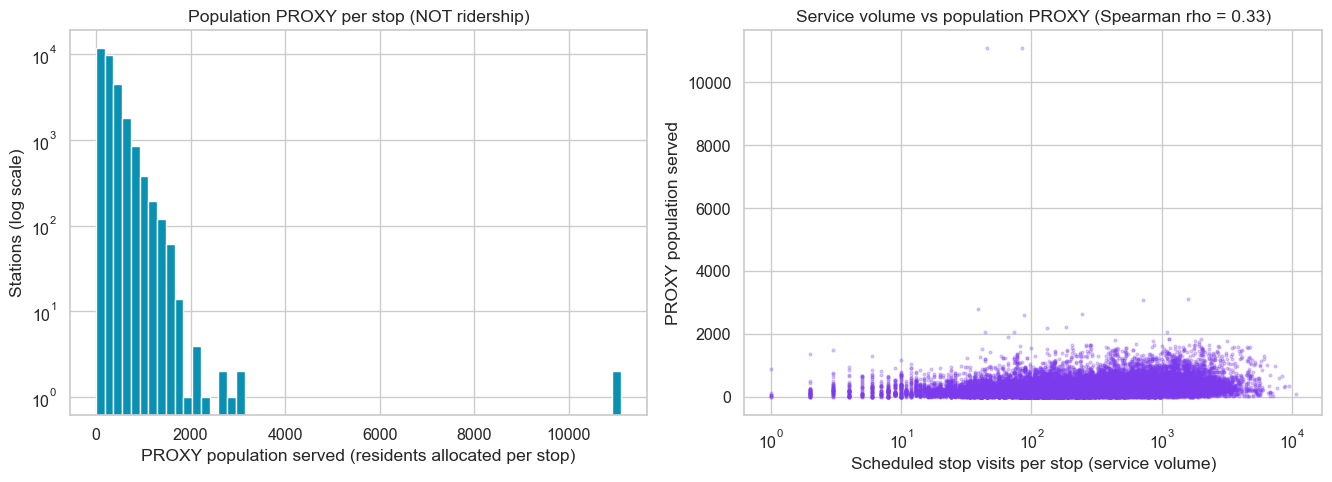

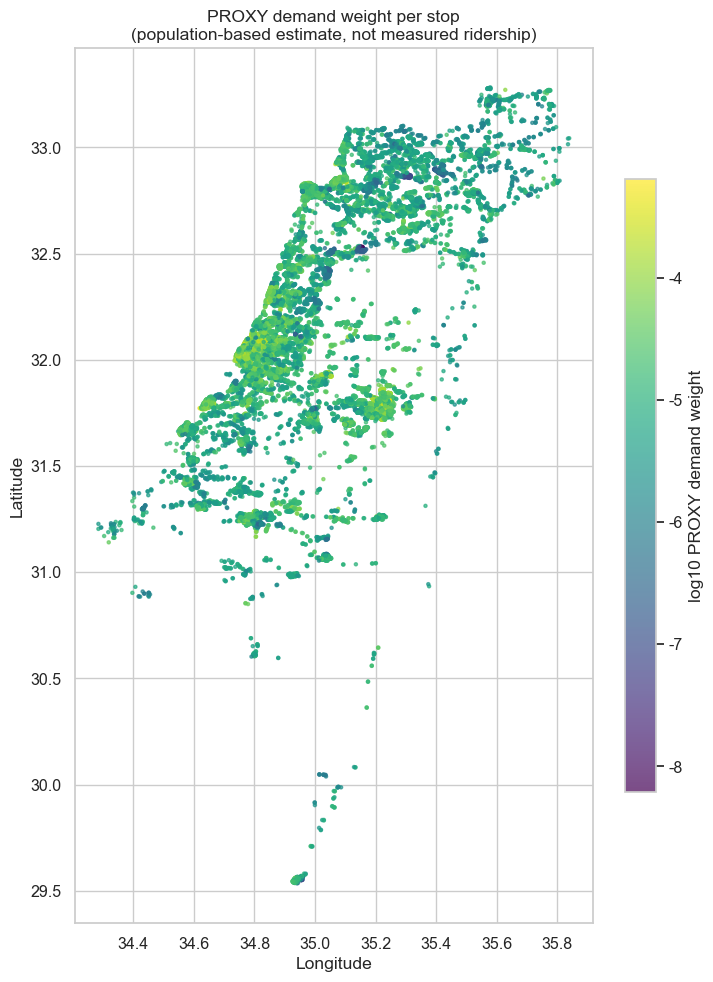

In [10]:
# --- Figures: what the demand PROXY looks like -----------------------------
served = proxy['population_served'].astype(float)
use = pd.to_numeric(proxy['stop_use_count'], errors='coerce').fillna(0.0)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))
axes[0].hist(served[served > 0], bins=60, color='#0891b2')
axes[0].set_yscale('log')
axes[0].set_xlabel('PROXY population served (residents allocated per stop)')
axes[0].set_ylabel('Stations (log scale)')
axes[0].set_title('Population PROXY per stop (NOT ridership)')

axes[1].scatter(use.where(use > 0), served, s=4, alpha=0.25, color='#7c3aed')
axes[1].set_xscale('log')
axes[1].set_xlabel('Scheduled stop visits per stop (service volume)')
axes[1].set_ylabel('PROXY population served')
axes[1].set_title(f'Service volume vs population PROXY (Spearman rho = {rho_pop_service:.2f})')
fig.tight_layout()
fig.savefig(FIGURES / 'demand_proxy_distribution.png', dpi=FIG_DPI)
plt.show()

geo = proxy.dropna(subset=['lat', 'lon']).copy()
geo = geo[geo['demand_weight'] > 0]
if len(geo):
    fig, ax = plt.subplots(figsize=(7.5, 10))
    sc = ax.scatter(geo['lon'], geo['lat'], s=5,
                    c=np.log10(geo['demand_weight'] + 1e-12),
                    cmap='viridis', alpha=0.7)
    fig.colorbar(sc, ax=ax, shrink=0.7, label='log10 PROXY demand weight')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title('PROXY demand weight per stop\n(population-based estimate, not measured ridership)')
    fig.tight_layout()
    fig.savefig(FIGURES / 'demand_proxy_map.png', dpi=FIG_DPI)
    plt.show()
else:
    print('No stop has both coordinates and a positive PROXY weight - skipping the map.')

## 11. The demand-weighted betweenness estimator

Standard betweenness gives every ordered stop pair equal weight. I want to estimate

```
BC_demand(v) = sum over s != v != t of  w(s) * w(t) * sigma_st(v) / sigma_st
```

where `w` is the proxy demand weight. NetworkX does not support endpoint weights in `betweenness_centrality`, so I implement the Brandes accumulation with two changes:

* **Destination weighting.** During the backward pass I replace the usual unit destination term with the destination's demand weight, so higher-weight endpoints contribute more dependency.
* **Demand-proportional source sampling.** Computing every source is too slow, so I draw `K_DEMAND_SOURCES` sources with replacement using probability `w(s) / sum(w)`, accumulate dependencies, and rescale by `sum(w) / k`. Matching the sampling probability to the source weight gives an unbiased estimate of the weighted source sum.

Setting every `w` to 1 gives an ordinary sampled-betweenness ranking up to a constant factor. I use that as the uniform control because it shares the same code and source count as the demand lens.

Each sampled source requires one breadth-first search and one dependency pass over the largest component. At `k = 400`, each lens takes minutes rather than hours. The estimate remains noisy for individual low-ranked stations, so I focus later comparisons on the better-resolved upper part of the ranking.

In [11]:
# --- Brandes betweenness with demand-weighted endpoints, sampled sources ---
def sampled_endpoint_weighted_betweenness(graph, node_weight, k, seed,
                                          progress_every=None, label=''):
    """Estimate sum_{s,t} w(s) w(t) sigma_st(v) / sigma_st for every v.

    Sources are drawn with replacement with probability proportional to
    `node_weight`; targets contribute their own weight inside the Brandes
    accumulation. The estimate is unbiased for any k.
    """
    nodes = list(graph.nodes)
    weights = np.array([float(node_weight.get(n, 0.0)) for n in nodes], dtype=float)
    weights[~np.isfinite(weights)] = 0.0
    weights[weights < 0] = 0.0
    total_weight = float(weights.sum())
    if total_weight <= 0:
        raise ValueError('every node weight is zero - cannot sample sources')

    rng = np.random.default_rng(seed)
    draws = rng.choice(len(nodes), size=int(k), replace=True, p=weights / total_weight)
    target_weight = {n: float(weights[i]) for i, n in enumerate(nodes)}
    scores = dict.fromkeys(nodes, 0.0)

    t_start = time.time()
    for step, source_index in enumerate(draws, start=1):
        s = nodes[source_index]
        # ---- forward pass: BFS shortest-path DAG (hop distance) ----
        stack = []
        preds = {s: []}
        sigma = {s: 1.0}
        dist = {s: 0}
        queue = deque([s])
        while queue:
            v = queue.popleft()
            stack.append(v)
            dist_v = dist[v]
            sigma_v = sigma[v]
            for nbr in graph[v]:
                if nbr not in dist:
                    dist[nbr] = dist_v + 1
                    sigma[nbr] = 0.0
                    preds[nbr] = []
                    queue.append(nbr)
                if dist[nbr] == dist_v + 1:
                    sigma[nbr] += sigma_v
                    preds[nbr].append(v)
        # ---- backward pass: dependency accumulation, targets weighted ----
        delta = dict.fromkeys(stack, 0.0)
        while stack:
            w_node = stack.pop()
            coeff = (target_weight[w_node] + delta[w_node]) / sigma[w_node]
            for v in preds[w_node]:
                delta[v] += sigma[v] * coeff
            if w_node != s:
                scores[w_node] += delta[w_node]
        if progress_every and step % progress_every == 0:
            elapsed = time.time() - t_start
            print(f'  [{label}] {step}/{len(draws)} sources, {elapsed:.0f}s elapsed, '
                  f'~{elapsed / step * (len(draws) - step):.0f}s left')

    scale = total_weight / len(draws)
    meta = {'k': int(len(draws)), 'seed': int(seed),
            'total_weight': total_weight,
            'distinct_sources': int(len(set(draws.tolist()))),
            'seconds': round(time.time() - t_start, 1)}
    return {n: value * scale for n, value in scores.items()}, meta


print('estimator defined')

estimator defined


## 12. Running the two lenses

I now run the estimator twice on the largest connected component:

* **Uniform control** assigns weight 1 to every node. This isolates the effect of weighting because it uses the same estimator and sample size as the demand run. I still compare with notebook 04, but that comparison also includes different sampled sources.
* **Demand-weighted proxy** uses `demand_weight`. Zero-weight stops are not sampled as sources and add no destination weight, although they can still receive a score by lying between other endpoints.

This is the main runtime cost. I print progress and an estimated time remaining every `PROGRESS_EVERY` sources.

In [12]:
# --- Run the uniform control lens and the demand-weighted PROXY lens -------
demand_lookup = dict(zip(proxy['stop_id'], proxy['demand_weight'].astype(float)))
demand_weight_lcc = {n: demand_lookup.get(n, 0.0) for n in Gc.nodes}
uniform_weight_lcc = {n: 1.0 for n in Gc.nodes}

covered = sum(1 for v in demand_weight_lcc.values() if v > 0)
print(f'LCC stations with a positive PROXY weight: {covered:,} of {len(demand_weight_lcc):,} '
      f'({covered / len(demand_weight_lcc):.1%})')
print(f'share of the national PROXY weight inside the LCC: '
      f'{sum(demand_weight_lcc.values()):.3%}\n')

print('running the uniform-weight control lens ...')
uniform_scores, uniform_meta = sampled_endpoint_weighted_betweenness(
    Gc, uniform_weight_lcc, K_DEMAND_SOURCES, SEED_UNIFORM,
    progress_every=PROGRESS_EVERY, label='uniform')
print(f'  done in {uniform_meta["seconds"]}s '
      f'({uniform_meta["distinct_sources"]} distinct sources)\n')

print('running the demand-weighted PROXY lens ...')
demand_scores, demand_meta = sampled_endpoint_weighted_betweenness(
    Gc, demand_weight_lcc, K_DEMAND_SOURCES, SEED_DEMAND,
    progress_every=PROGRESS_EVERY, label='demand')
print(f'  done in {demand_meta["seconds"]}s '
      f'({demand_meta["distinct_sources"]} distinct sources)')

LCC stations with a positive PROXY weight: 29,650 of 30,237 (98.1%)
share of the national PROXY weight inside the LCC: 99.168%

running the uniform-weight control lens ...


  [uniform] 50/400 sources, 4s elapsed, ~26s left


  [uniform] 100/400 sources, 8s elapsed, ~24s left


  [uniform] 150/400 sources, 12s elapsed, ~19s left


  [uniform] 200/400 sources, 15s elapsed, ~15s left


...

  [demand] 200/400 sources, 17s elapsed, ~17s left


  [demand] 250/400 sources, 21s elapsed, ~13s left


  [demand] 300/400 sources, 25s elapsed, ~8s left


  [demand] 350/400 sources, 29s elapsed, ~4s left


  [demand] 400/400 sources, 32s elapsed, ~0s left
  done in 32.4s (391 distinct sources)


## 13. Assembling the rankings and writing the contract table

I combine three score columns in one table:

* `topological_betweenness_nb04` - notebook 04's approximate topological baseline;
* `uniform_control_betweenness` - the control from the same estimator;
* `demand_weighted_betweenness_proxy` - the population/service-weighted lens.

I convert each score to a rank with 1 as the most critical and use average ranks for ties. This avoids inventing an order among the many stops with exactly zero sampled score.

`rank_shift = topological_rank - demand_weighted_rank`. Positive values mean the station rises after weighting; negative values mean it falls. I write the compact comparison to `demand_weighted_criticality.csv` and keep scores, coordinates, socioeconomic cluster, and the control lens in `criticality_lens_detail.csv`.

In [13]:
# --- Join the three lenses, rank them, write the contract table ------------
lenses = proxy[['stop_id', 'stop_name', 'lat', 'lon', 'region', 'metro',
                'socio_cluster', 'stop_use_count', 'population_served',
                'demand_weight']].copy()

nb04_betweenness = dict(zip(metrics_df['stop_id'],
                            pd.to_numeric(metrics_df['approx_betweenness'],
                                          errors='coerce').fillna(0.0)))
lenses['topological_betweenness_nb04'] = lenses['stop_id'].map(nb04_betweenness).fillna(0.0)
lenses['uniform_control_betweenness'] = lenses['stop_id'].map(uniform_scores).fillna(0.0)
lenses['demand_weighted_betweenness_proxy'] = lenses['stop_id'].map(demand_scores).fillna(0.0)
lenses['in_largest_component'] = lenses['stop_id'].isin(LCC_NODES)

RANK_OF = {
    'topological_betweenness_nb04': 'topological_rank',
    'uniform_control_betweenness': 'uniform_control_rank',
    'demand_weighted_betweenness_proxy': 'demand_weighted_rank',
}
for score_col, rank_col in RANK_OF.items():
    lenses[rank_col] = lenses[score_col].rank(ascending=False, method='average')

lenses['rank_shift'] = lenses['topological_rank'] - lenses['demand_weighted_rank']
lenses['rank_shift_vs_control'] = lenses['uniform_control_rank'] - lenses['demand_weighted_rank']
lenses['label'] = lenses['stop_name'].fillna('').astype(str).str.strip()
lenses['label'] = lenses['label'].where(lenses['label'] != '', lenses['stop_id'])

# --- contract table: exactly the five agreed columns -----------------------
(lenses[['stop_id', 'stop_name', 'topological_rank', 'demand_weighted_rank', 'rank_shift']]
    .sort_values('demand_weighted_rank')
    .to_csv(TABLES / 'demand_weighted_criticality.csv', index=False, encoding='utf-8-sig'))

(lenses.drop(columns=['label'])
       .sort_values('demand_weighted_rank')
       .to_csv(TABLES / 'criticality_lens_detail.csv', index=False, encoding='utf-8-sig'))

print(f'demand_weighted_criticality.csv written ({len(lenses):,} rows)')
print(f'stations with a non-zero demand-weighted score: '
      f'{int((lenses["demand_weighted_betweenness_proxy"] > 0).sum()):,}')
print(f'stations with a non-zero uniform control score: '
      f'{int((lenses["uniform_control_betweenness"] > 0).sum()):,}\n')
print('Top stations under the demand-weighted PROXY lens:')
lenses.nsmallest(TOP_N, 'demand_weighted_rank')[
    ['stop_name', 'region', 'socio_cluster', 'population_served',
     'topological_rank', 'demand_weighted_rank', 'rank_shift']].round(1)

demand_weighted_criticality.csv written (30,463 rows)
stations with a non-zero demand-weighted score: 27,216
stations with a non-zero uniform control score: 27,758

Top stations under the demand-weighted PROXY lens:


,stop_name,region,socio_cluster,population_served,topological_rank,demand_weighted_rank,rank_shift
155,מחלף חמד,Jerusalem,8.0,168.1,2.0,1.0,1.0
7865,דרך האר''י/ כביש 375,Jerusalem,2.0,188.7,4.0,2.0,2.0
2825,מחלף גבעת שמואל/כביש 4,Center,2.0,877.8,17.0,3.0,14.0
2854,מחלף חמד,Jerusalem,8.0,131.0,5.0,4.0,1.0
1175,שדרות בית הלל/כניסה לעיר,Center,2.0,246.6,6.0,5.0,1.0
4152,מחלף קמה לצפון,South,9.0,174.7,3.0,6.0,-3.0
1812,בית ספר הולץ/חיל השריון,Center,5.0,337.8,46.0,7.0,39.0
4148,ת.התרעננות/דור אלון מגל 6,Center,4.0,266.3,1.0,8.0,-7.0
984,מחלף מורשה,Center,3.0,177.1,31.0,9.0,22.0
3149,מחלף מסובים,Center,6.0,211.1,50.0,10.0,40.0


## 14. Do the two rankings agree?

For each pair of lenses I calculate three kinds of agreement:

* **Spearman rho over all stops.** The large low-score tail can make this high even when the priority list changes, so I do not use it alone.
* **Spearman rho over the union of the top-1000 sets.** This focuses on stations that at least one lens treats as important.
* **Top-N overlap** for the values in `OVERLAP_SIZES`. This directly measures how many stations remain on a fixed-size priority list.

My primary comparison is the uniform control against the demand proxy because the estimator and `k` are held fixed. I also include notebook 04's baseline, while remembering that it introduces an additional independent sample.

,lens_a,lens_b,spearman_all_stations,spearman_top1000_union,top50_overlap,top200_overlap,top1000_overlap
0,uniform control (same estimator),demand-weighted PROXY,0.8139,0.1243,0.58,0.635,0.461
1,topological nb04,demand-weighted PROXY,0.8163,0.1242,0.54,0.635,0.424
2,topological nb04,uniform control (same estimator),0.9571,0.3180,0.80,0.790,0.507


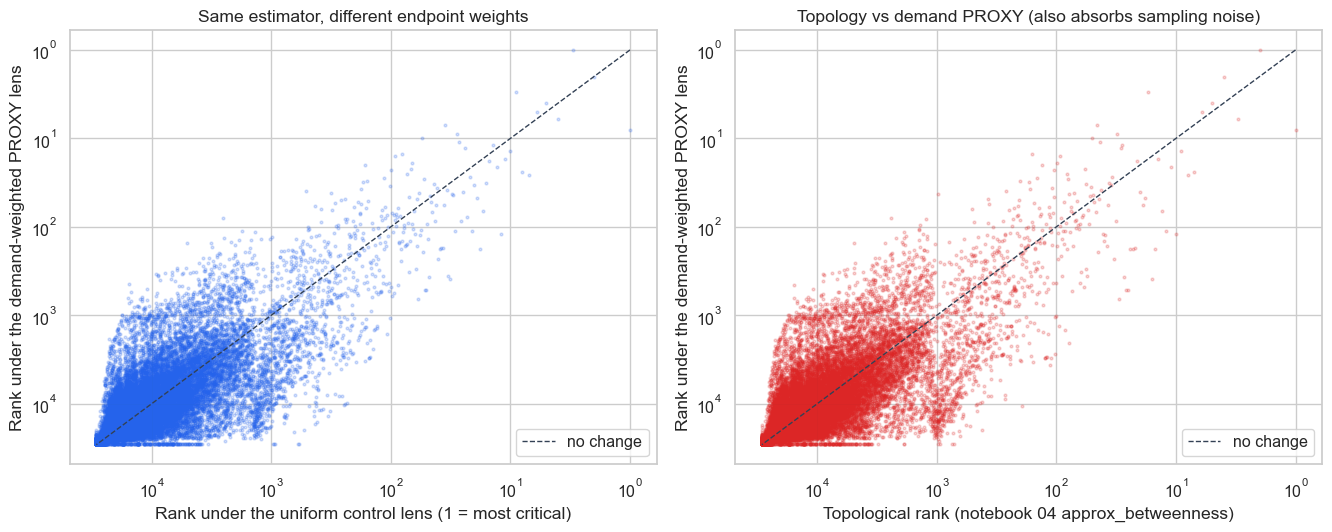

In [14]:
# --- Agreement between the lenses ------------------------------------------
PAIRS = [
    ('uniform_control_betweenness', 'demand_weighted_betweenness_proxy',
     'uniform control (same estimator)', 'demand-weighted PROXY'),
    ('topological_betweenness_nb04', 'demand_weighted_betweenness_proxy',
     'topological nb04', 'demand-weighted PROXY'),
    ('topological_betweenness_nb04', 'uniform_control_betweenness',
     'topological nb04', 'uniform control (same estimator)'),
]

rows = []
for col_a, col_b, name_a, name_b in PAIRS:
    a, b = lenses[col_a], lenses[col_b]
    top_union = set(lenses.nlargest(1000, col_a).index) | set(lenses.nlargest(1000, col_b).index)
    sub = lenses.loc[sorted(top_union)]
    row = {
        'lens_a': name_a,
        'lens_b': name_b,
        'spearman_all_stations': round(float(a.corr(b, method='spearman')), 4),
        'spearman_top1000_union': round(float(sub[col_a].corr(sub[col_b], method='spearman')), 4),
    }
    for n in OVERLAP_SIZES:
        set_a = set(lenses.nlargest(n, col_a)['stop_id'])
        set_b = set(lenses.nlargest(n, col_b)['stop_id'])
        row[f'top{n}_overlap'] = round(len(set_a & set_b) / n, 4)
    rows.append(row)

agreement = pd.DataFrame(rows)
agreement.to_csv(TABLES / 'rank_agreement.csv', index=False, encoding='utf-8-sig')
display(agreement)

ranked = lenses[lenses['in_largest_component']].copy()
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.5))
axes[0].scatter(ranked['uniform_control_rank'], ranked['demand_weighted_rank'],
                s=4, alpha=0.2, color='#2563eb')
lim = float(max(ranked['uniform_control_rank'].max(), ranked['demand_weighted_rank'].max()))
axes[0].plot([1, lim], [1, lim], ls='--', lw=1, color='#334155', label='no change')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].invert_xaxis()
axes[0].invert_yaxis()
axes[0].set_xlabel('Rank under the uniform control lens (1 = most critical)')
axes[0].set_ylabel('Rank under the demand-weighted PROXY lens')
axes[0].set_title('Same estimator, different endpoint weights')
axes[0].legend(loc='lower right')

axes[1].scatter(ranked['topological_rank'], ranked['demand_weighted_rank'],
                s=4, alpha=0.2, color='#dc2626')
lim2 = float(max(ranked['topological_rank'].max(), ranked['demand_weighted_rank'].max()))
axes[1].plot([1, lim2], [1, lim2], ls='--', lw=1, color='#334155', label='no change')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].invert_xaxis()
axes[1].invert_yaxis()
axes[1].set_xlabel('Topological rank (notebook 04 approx_betweenness)')
axes[1].set_ylabel('Rank under the demand-weighted PROXY lens')
axes[1].set_title('Topology vs demand PROXY (also absorbs sampling noise)')
axes[1].legend(loc='lower right')
fig.tight_layout()
fig.savefig(FIGURES / 'rank_rank_scatter.png', dpi=FIG_DPI)
plt.show()

## 15. Which stations move - the actual result

The station-level changes are more useful to me than one overall correlation. I extract the largest rank gains and losses between the topological and demand-weighted lenses.

I use two filters to keep the list meaningful:

1. A station must be in the largest component and have a nonzero score in at least one lens, which removes artificial movement inside the zero-score tie block.
2. A station must reach the top 2,000 in at least one lens. I do not interpret large numerical shifts deep in the poorly resolved tail.

`rank_movers.csv` contains both gainers and losers. I use the names and locations to see whether gainers tend to sit in dense residential areas and losers in sparsely populated or non-residential locations. Since both scores are sampled, I treat individual moderate shifts cautiously and look for repeated patterns across the list.

eligible stations for the movers analysis: 3,059
median |rank shift| among them            : 2,031 places

Biggest GAINERS (topology under-rates them once population is weighted in):


,stop_name,region,socio_cluster,population_served,stop_use_count,topological_rank,demand_weighted_rank,rank_shift
2807,רבי יהודה הנשיא/בארי,Center,2.0,1310.6,689,22490.0,1880.0,20610.0
4610,עולי הגרדום/החייל האלמוני,Center,6.0,946.0,555,21295.0,1960.0,19335.0
17733,רבינוביץ'/לסקוב,Center,7.0,738.5,533,20815.0,1862.0,18953.0
8297,אליהו בן חור/אלוף רחבעם זאבי,Center,8.0,1833.0,1130,20769.0,1891.0,18878.0
18902,לוס אנג'לס/סיני,South,4.0,368.4,106,20556.0,1849.0,18707.0
17735,מרכז סאדאב/רבינוביץ,Center,7.0,592.7,533,20472.0,1770.0,18702.0
9591,דרך הר הזיתים/נשאשיבי,Jerusalem,2.0,319.3,513,20464.0,1848.0,18616.0
7003,אבא הלל סילבר/הארי טרומן,Jerusalem,2.0,392.3,1975,19826.0,1767.0,18059.0
27310,רמ''א/השדרה,Center,7.0,171.2,212,19567.0,1528.0,18039.0
8184,היוצרים/המסגר,Center,6.0,387.4,820,19433.0,1456.0,17977.0


Biggest LOSERS (topologically central, but few residents nearby):


,stop_name,region,socio_cluster,population_served,stop_use_count,topological_rank,demand_weighted_rank,rank_shift
14847,תיכון אורט,North,NaN,0.0,782,718.0,28840.0,-28122.0
18586,צומת אלמחרקה,North,NaN,0.0,880,740.0,28840.0,-28100.0
19620,מצפה כרמל,North,NaN,0.0,98,934.5,28840.0,-27905.5
19619,בי''ס טכנולוגי,North,NaN,0.0,98,979.0,28840.0,-27861.0
5458,ואדי אלפאש,North,NaN,0.0,967,1865.0,28840.0,-26975.0
5459,תחנת דלק,North,NaN,0.0,969,1885.0,28840.0,-26955.0
23937,שדרות עמק יזרעאל/עין עבדת,Center,5.0,175.7,406,967.0,26125.0,-25158.0
4717,כיכר אל-ג'ליל,North,6.0,1.4,233,985.0,25332.0,-24347.0
28775,אל הרובה ב',North,9.0,9.6,113,1054.0,24581.0,-23527.0
28774,אל הרובה א',North,9.0,10.3,113,1021.0,23742.0,-22721.0


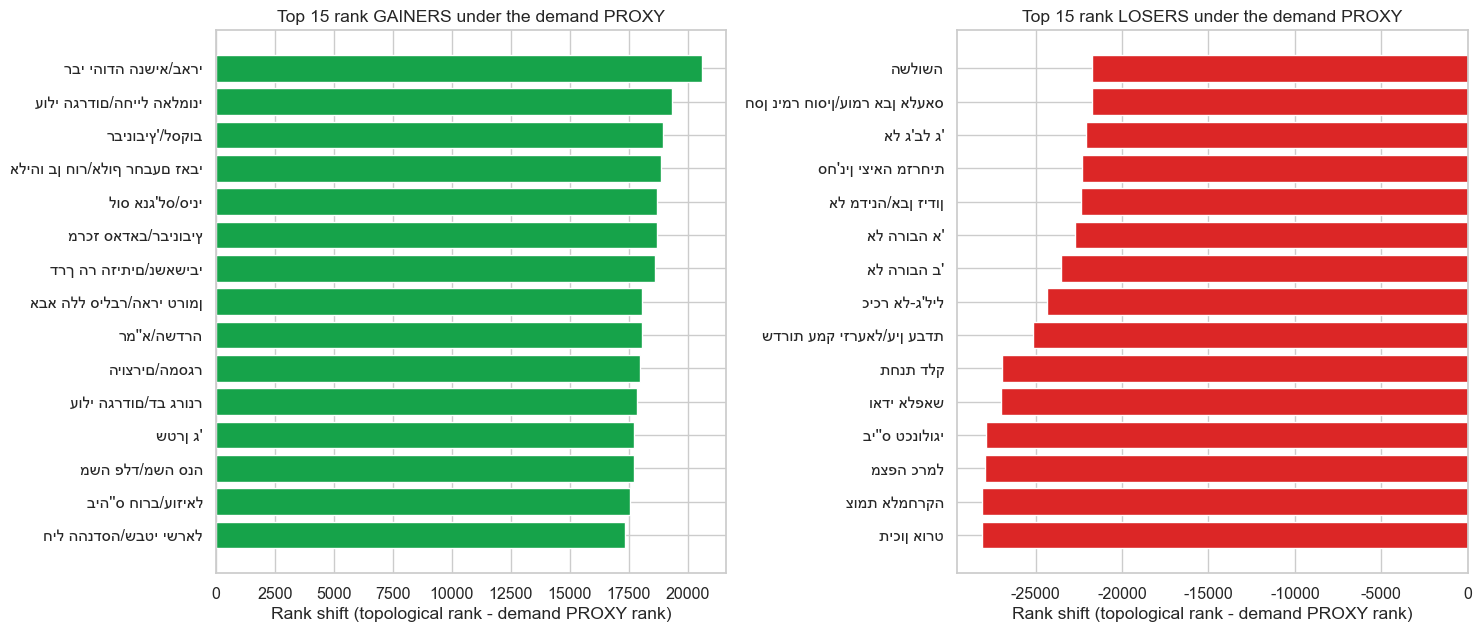

In [15]:
# --- Biggest gainers and losers of rank ------------------------------------
eligible = lenses[
    lenses['in_largest_component']
    & ((lenses['topological_betweenness_nb04'] > 0)
       | (lenses['demand_weighted_betweenness_proxy'] > 0))
    & ((lenses['topological_rank'] <= 2000) | (lenses['demand_weighted_rank'] <= 2000))
].copy()

gainers = eligible.nlargest(MOVERS_N, 'rank_shift').copy()
losers = eligible.nsmallest(MOVERS_N, 'rank_shift').copy()
gainers['direction'] = 'gains under demand PROXY'
losers['direction'] = 'loses under demand PROXY'

MOVER_COLS = ['direction', 'stop_id', 'stop_name', 'region', 'metro', 'socio_cluster',
              'population_served', 'stop_use_count', 'topological_rank',
              'demand_weighted_rank', 'uniform_control_rank', 'rank_shift',
              'rank_shift_vs_control']
movers = pd.concat([gainers, losers])[MOVER_COLS]
movers.to_csv(TABLES / 'rank_movers.csv', index=False, encoding='utf-8-sig')

print(f'eligible stations for the movers analysis: {len(eligible):,}')
print(f'median |rank shift| among them            : '
      f'{eligible["rank_shift"].abs().median():,.0f} places\n')
print('Biggest GAINERS (topology under-rates them once population is weighted in):')
display(gainers[['stop_name', 'region', 'socio_cluster', 'population_served',
                 'stop_use_count', 'topological_rank', 'demand_weighted_rank',
                 'rank_shift']].round(1).head(TOP_N))
print('Biggest LOSERS (topologically central, but few residents nearby):')
display(losers[['stop_name', 'region', 'socio_cluster', 'population_served',
                'stop_use_count', 'topological_rank', 'demand_weighted_rank',
                'rank_shift']].round(1).head(TOP_N))

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
for ax, frame, colour, title in [
    (axes[0], gainers.head(TOP_N), '#16a34a',
     f'Top {TOP_N} rank GAINERS under the demand PROXY'),
    (axes[1], losers.head(TOP_N), '#dc2626',
     f'Top {TOP_N} rank LOSERS under the demand PROXY'),
]:
    frame = frame.sort_values('rank_shift')
    y = np.arange(len(frame))
    ax.barh(y, frame['rank_shift'].astype(float).values, color=colour)
    ax.set_yticks(y)
    ax.set_yticklabels(frame['stop_name'].fillna('').astype(str)
                            .where(frame['stop_name'].notna(), frame['stop_id']).values)
    ax.set_xlabel('Rank shift (topological rank - demand PROXY rank)')
    ax.set_title(title)
fig.tight_layout()
fig.savefig(FIGURES / 'rank_movers.png', dpi=FIG_DPI)
plt.show()

## 16. Does demand weighting change *who* the network protects?

I also group rank shifts by socioeconomic cluster to see whether demand weighting changes the areas emphasized by a topological priority list. If lower-cluster areas consistently gain rank, the unweighted structure may miss population exposure there; if the shifts are flat, this data does not support that pattern.

I calculate mean and median `rank_shift`, station count, and change in top-200 representation for CBS clusters 1 through 10. Population density is related to socioeconomic cluster and is built directly into my proxy, so I interpret any cluster trend as descriptive rather than causal.

,socio_cluster,stations,mean_rank_shift,median_rank_shift,mean_population_served,top200_topological,top200_demand,top200_change
0,1,1203,1988.20,1382.5,514.97,2,10,8
1,2,3092,1357.58,713.0,329.94,29,39,10
2,3,3119,35.27,168.0,264.01,18,14,-4
3,4,2053,137.16,168.0,271.86,18,13,-5
4,5,4421,222.35,168.0,269.13,34,31,-3
5,6,3394,-270.79,168.0,245.61,24,18,-6
6,7,5893,-602.23,168.0,271.29,25,25,0
7,8,3322,134.67,168.0,306.02,23,25,2
8,9,3437,-55.99,168.0,296.22,27,25,-2
9,10,126,1155.08,168.0,232.10,0,0,0


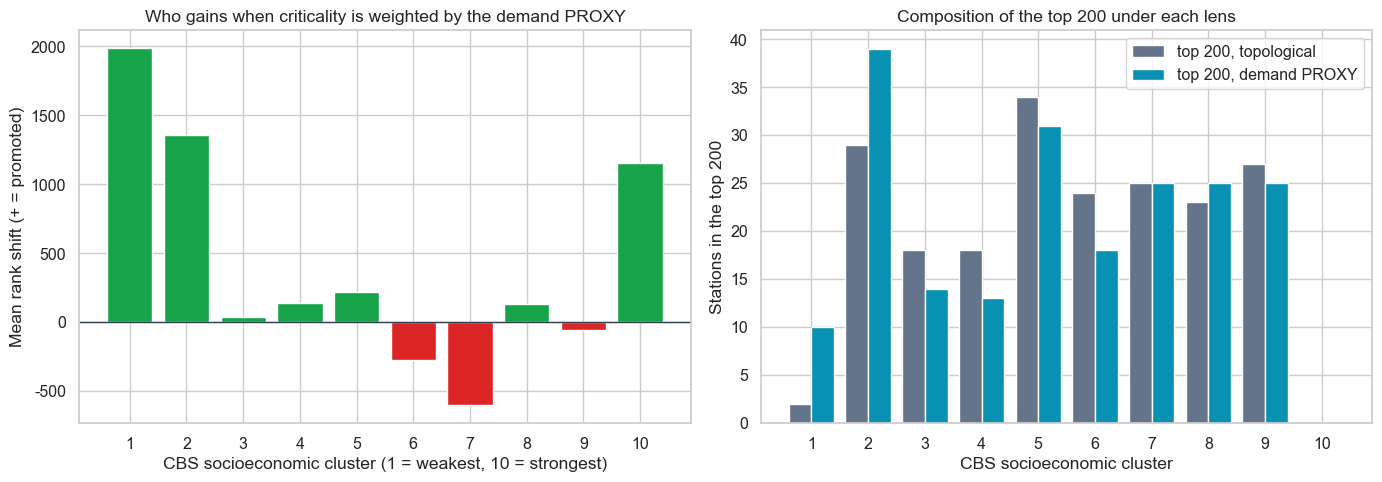

In [16]:
# --- Rank movement by CBS socioeconomic cluster ----------------------------
cluster_frame = lenses.dropna(subset=['socio_cluster']).copy()
cluster_frame['socio_cluster'] = cluster_frame['socio_cluster'].astype(float).round().astype(int)

top_topo = set(lenses.nsmallest(200, 'topological_rank')['stop_id'])
top_demand = set(lenses.nsmallest(200, 'demand_weighted_rank')['stop_id'])
cluster_frame['in_top200_topological'] = cluster_frame['stop_id'].isin(top_topo)
cluster_frame['in_top200_demand'] = cluster_frame['stop_id'].isin(top_demand)

by_cluster = (cluster_frame
              .groupby('socio_cluster')
              .agg(stations=('stop_id', 'size'),
                   mean_rank_shift=('rank_shift', 'mean'),
                   median_rank_shift=('rank_shift', 'median'),
                   mean_population_served=('population_served', 'mean'),
                   top200_topological=('in_top200_topological', 'sum'),
                   top200_demand=('in_top200_demand', 'sum'))
              .reset_index())
by_cluster['top200_change'] = by_cluster['top200_demand'] - by_cluster['top200_topological']
by_cluster = by_cluster.round(2)
by_cluster.to_csv(TABLES / 'rank_shift_by_socioeconomic_cluster.csv',
                  index=False, encoding='utf-8-sig')
display(by_cluster)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colours = ['#16a34a' if v >= 0 else '#dc2626' for v in by_cluster['mean_rank_shift']]
axes[0].bar(by_cluster['socio_cluster'].astype(str), by_cluster['mean_rank_shift'], color=colours)
axes[0].axhline(0, color='#334155', lw=1)
axes[0].set_xlabel('CBS socioeconomic cluster (1 = weakest, 10 = strongest)')
axes[0].set_ylabel('Mean rank shift (+ = promoted)')
axes[0].set_title('Who gains when criticality is weighted by the demand PROXY')

width = 0.4
pos = np.arange(len(by_cluster))
axes[1].bar(pos - width / 2, by_cluster['top200_topological'], width,
            label='top 200, topological', color='#64748b')
axes[1].bar(pos + width / 2, by_cluster['top200_demand'], width,
            label='top 200, demand PROXY', color='#0891b2')
axes[1].set_xticks(pos)
axes[1].set_xticklabels(by_cluster['socio_cluster'].astype(str))
axes[1].set_xlabel('CBS socioeconomic cluster')
axes[1].set_ylabel('Stations in the top 200')
axes[1].set_title('Composition of the top 200 under each lens')
axes[1].legend()
fig.tight_layout()
fig.savefig(FIGURES / 'rank_shift_by_socioeconomic_cluster.png', dpi=FIG_DPI)
plt.show()

## 17. How much do the proxy's arbitrary parameters matter?

The catchment radius, decay length, and service exponent are modeling choices rather than measured constants. I check their influence in two stages:

* **Weight sensitivity (`RUN_WEIGHT_SENSITIVITY`).** I rebuild `demand_weight` across `RADIUS_GRID x SERVICE_EXPONENT_GRID` and compare each variant with the base weights using Spearman correlation.
* **Ranking sensitivity (`RUN_BETWEENNESS_SENSITIVITY`).** I rerun the estimator with `SENSITIVITY_K = 150` for a pure-population proxy and a wider catchment. The pure-population case is especially useful because it removes the service term completely.

The sensitivity runs use fewer sources than the base run, so their disagreement combines parameter effects with sampling noise. I also rerun the base proxy at `SENSITIVITY_K` to estimate that noise level.

In [17]:
# --- Sensitivity of the PROXY to its arbitrary parameters ------------------
baseline_weight = proxy['demand_weight'].to_numpy()
weight_rows = []

if RUN_WEIGHT_SENSITIVITY:
    served_by_radius = {}
    for radius in RADIUS_GRID:
        decay = radius / 2.0
        t0 = time.time()
        served_by_radius[radius] = allocate_population(
            proxy['lat'].to_numpy(), proxy['lon'].to_numpy(),
            proxy['area_population_share'].to_numpy(), radius, decay)
        print(f'  radius {radius:.0f} m / decay {decay:.0f} m: {time.time() - t0:.1f}s')
    for radius in RADIUS_GRID:
        for exponent in SERVICE_EXPONENT_GRID:
            variant = build_demand_weight(served_by_radius[radius],
                                          proxy['stop_use_count'], exponent)
            weight_rows.append({
                'catchment_radius_m': radius,
                'decay_length_m': radius / 2.0,
                'service_exponent': exponent,
                'is_baseline': bool(radius == CATCHMENT_RADIUS_M
                                    and exponent == SERVICE_EXPONENT),
                'spearman_vs_baseline_weight': round(float(
                    pd.Series(variant).corr(pd.Series(baseline_weight), method='spearman')), 4),
                'top200_overlap_vs_baseline': round(float(len(
                    set(pd.Series(variant, index=proxy['stop_id']).nlargest(200).index)
                    & set(pd.Series(baseline_weight, index=proxy['stop_id']).nlargest(200).index)
                ) / 200), 4),
            })
    weight_sensitivity = pd.DataFrame(weight_rows)
    weight_sensitivity.to_csv(TABLES / 'proxy_sensitivity.csv',
                              index=False, encoding='utf-8-sig')
    display(weight_sensitivity)
else:
    weight_sensitivity = pd.DataFrame()
    print('RUN_WEIGHT_SENSITIVITY is False - skipped.')

  radius 300 m / decay 150 m: 0.4s


  radius 500 m / decay 250 m: 0.4s


  radius 1000 m / decay 500 m: 0.4s


,catchment_radius_m,decay_length_m,service_exponent,is_baseline,spearman_vs_baseline_weight,top200_overlap_vs_baseline
0,300.0,150.0,0.0,False,0.8292,0.445
1,300.0,150.0,0.5,False,0.9867,0.790
2,300.0,150.0,1.0,False,0.9687,0.755
3,500.0,250.0,0.0,False,0.8543,0.480
4,500.0,250.0,0.5,True,1.0000,1.000
5,500.0,250.0,1.0,False,0.9725,0.780
6,1000.0,500.0,0.0,False,0.8428,0.375
7,1000.0,500.0,0.5,False,0.9765,0.700
8,1000.0,500.0,1.0,False,0.9461,0.610


### 17b. Sensitivity of the ranking itself

Weight correlations do not necessarily imply the same centrality ranking. I rerun betweenness for the two alternative proxies and compare their ranks with the base lens using Spearman and top-N overlap. A smaller base-proxy rerun gives me a sampling reference for interpreting those differences.

In [18]:
# --- Does the RANKING move when the PROXY definition moves? ----------------
betweenness_sensitivity = pd.DataFrame()
if RUN_BETWEENNESS_SENSITIVITY:
    baseline_series = lenses.set_index('stop_id')['demand_weighted_betweenness_proxy']

    served_pure = proxy['population_served'].to_numpy()
    served_wide = allocate_population(proxy['lat'].to_numpy(), proxy['lon'].to_numpy(),
                                      proxy['area_population_share'].to_numpy(), 1000.0, 500.0)
    VARIANTS = [
        ('noise_floor_baseline_k150', build_demand_weight(
            served_pure, proxy['stop_use_count'], SERVICE_EXPONENT), 101),
        ('pure_population_no_service', build_demand_weight(
            served_pure, proxy['stop_use_count'], 0.0), 102),
        ('wide_catchment_1km', build_demand_weight(
            served_wide, proxy['stop_use_count'], SERVICE_EXPONENT), 103),
    ]

    rows = []
    for name, weight_vector, seed in VARIANTS:
        lookup = dict(zip(proxy['stop_id'], weight_vector))
        weights_lcc = {n: float(lookup.get(n, 0.0)) for n in Gc.nodes}
        print(f'running variant "{name}" at k={SENSITIVITY_K} ...')
        scores, meta = sampled_endpoint_weighted_betweenness(
            Gc, weights_lcc, SENSITIVITY_K, seed,
            progress_every=PROGRESS_EVERY, label=name)
        variant_series = pd.Series(scores).reindex(baseline_series.index).fillna(0.0)
        row = {
            'variant': name,
            'k_sources': meta['k'],
            'seconds': meta['seconds'],
            'spearman_vs_baseline_lens': round(float(
                variant_series.corr(baseline_series, method='spearman')), 4),
        }
        for n in OVERLAP_SIZES:
            row[f'top{n}_overlap_vs_baseline'] = round(float(len(
                set(variant_series.nlargest(n).index) & set(baseline_series.nlargest(n).index)
            ) / n), 4)
        rows.append(row)
        print(f'  {name}: rho = {row["spearman_vs_baseline_lens"]}, '
              f'top50 overlap = {row["top50_overlap_vs_baseline"]}\n')

    betweenness_sensitivity = pd.DataFrame(rows)
    betweenness_sensitivity.to_csv(TABLES / 'betweenness_sensitivity.csv',
                                   index=False, encoding='utf-8-sig')
    display(betweenness_sensitivity)
else:
    print('RUN_BETWEENNESS_SENSITIVITY is False - skipped. '
          'The parameter robustness of the ranking is then untested.')

running variant "noise_floor_baseline_k150" at k=150 ...


  [noise_floor_baseline_k150] 50/150 sources, 4s elapsed, ~9s left


  [noise_floor_baseline_k150] 100/150 sources, 8s elapsed, ~4s left


  [noise_floor_baseline_k150] 150/150 sources, 12s elapsed, ~0s left
  noise_floor_baseline_k150: rho = 0.9758, top50 overlap = 0.68

running variant "pure_population_no_service" at k=150 ...


  [pure_population_no_service] 50/150 sources, 4s elapsed, ~7s left


...

  [pure_population_no_service] 150/150 sources, 11s elapsed, ~0s left
  pure_population_no_service: rho = 0.9483, top50 overlap = 0.64

running variant "wide_catchment_1km" at k=150 ...


  [wide_catchment_1km] 50/150 sources, 4s elapsed, ~7s left


  [wide_catchment_1km] 100/150 sources, 8s elapsed, ~4s left


  [wide_catchment_1km] 150/150 sources, 12s elapsed, ~0s left
  wide_catchment_1km: rho = 0.9722, top50 overlap = 0.7



,variant,k_sources,seconds,spearman_vs_baseline_lens,top50_overlap_vs_baseline,top200_overlap_vs_baseline,top1000_overlap_vs_baseline
0,noise_floor_baseline_k150,150,12.5,0.9758,0.68,0.715,0.509
1,pure_population_no_service,150,11.1,0.9483,0.64,0.645,0.508
2,wide_catchment_1km,150,11.6,0.9722,0.70,0.735,0.518


## 18. Summary JSON

I collect the proxy parameters, coverage, join limitations, estimator settings, lens-agreement statistics, and largest rank movers in `demand_summary.json`. I also store `proxy_is_not_ridership: true` so the main interpretation limit travels with the results.

In [19]:
# --- demand_summary.json ---------------------------------------------------
def _agreement(name_a, name_b, key):
    hit = agreement[(agreement['lens_a'] == name_a) & (agreement['lens_b'] == name_b)]
    return float(hit.iloc[0][key]) if len(hit) else None


top_gainer = gainers.iloc[0] if len(gainers) else None
top_loser = losers.iloc[0] if len(losers) else None

summary = {
    'stage': '21_demand_weighted_criticality',
    'proxy_is_not_ridership': True,
    'proxy_description': ('CBS 2021 statistical-area population split across the stops of '
                          'each area, re-allocated with a distance-decayed gravity kernel, '
                          'then multiplied by scheduled service volume. GTFS contains no '
                          'boarding, alighting or ridership data of any kind.'),
    'parameters': {
        'catchment_radius_m': CATCHMENT_RADIUS_M,
        'decay_length_m': DECAY_LENGTH_M,
        'service_exponent': SERVICE_EXPONENT,
        'k_sources_per_lens': K_DEMAND_SOURCES,
        'seed_demand': SEED_DEMAND,
        'seed_uniform_control': SEED_UNIFORM,
        'shortest_paths': 'unweighted hop count, undirected projection, largest component',
    },
    'network': {
        'stops': int(len(lenses)),
        'largest_component_nodes': int(Gc.number_of_nodes()),
        'largest_component_edges': int(Gc.number_of_edges()),
        'largest_component_share': round(Gc.number_of_nodes() / G.number_of_nodes(), 4),
    },
    'proxy_coverage': {
        'cbs_population_total': round(national_population, 0),
        'population_allocated_to_stops': round(allocated, 0),
        'stops_without_cbs_unit': no_unit,
        'stops_whose_unit_has_no_population': no_population,
        'stops_with_zero_demand_weight': int((proxy['demand_weight'] <= 0).sum()),
        'demand_weight_share_of_top_1_percent_of_stops': round(share_top1pct, 4),
        'spearman_population_proxy_vs_service_volume': round(rho_pop_service, 4),
    },
    'agreement': {
        'control_vs_demand_spearman': _agreement(
            'uniform control (same estimator)', 'demand-weighted PROXY',
            'spearman_all_stations'),
        'control_vs_demand_top50_overlap': _agreement(
            'uniform control (same estimator)', 'demand-weighted PROXY', 'top50_overlap'),
        'nb04_vs_demand_spearman': _agreement(
            'topological nb04', 'demand-weighted PROXY', 'spearman_all_stations'),
        'nb04_vs_demand_top50_overlap': _agreement(
            'topological nb04', 'demand-weighted PROXY', 'top50_overlap'),
        'nb04_vs_control_spearman': _agreement(
            'topological nb04', 'uniform control (same estimator)', 'spearman_all_stations'),
        'median_abs_rank_shift_top2000': float(eligible['rank_shift'].abs().median()),
    },
    'biggest_gainer': (None if top_gainer is None else {
        'stop_id': str(top_gainer['stop_id']),
        'stop_name': str(top_gainer['stop_name']),
        'topological_rank': float(top_gainer['topological_rank']),
        'demand_weighted_rank': float(top_gainer['demand_weighted_rank']),
        'rank_shift': float(top_gainer['rank_shift']),
    }),
    'biggest_loser': (None if top_loser is None else {
        'stop_id': str(top_loser['stop_id']),
        'stop_name': str(top_loser['stop_name']),
        'topological_rank': float(top_loser['topological_rank']),
        'demand_weighted_rank': float(top_loser['demand_weighted_rank']),
        'rank_shift': float(top_loser['rank_shift']),
    }),
    'sensitivity_run': {
        'weight_level': bool(RUN_WEIGHT_SENSITIVITY),
        'betweenness_level': bool(RUN_BETWEENNESS_SENSITIVITY),
        'sensitivity_k': SENSITIVITY_K,
    },
    'outputs': sorted(p.name for p in TABLES.glob('*.csv')),
}

with open(STAGE / 'demand_summary.json', 'w', encoding='utf-8') as handle:
    json.dump(summary, handle, ensure_ascii=False, indent=2)

print(json.dumps(summary, ensure_ascii=False, indent=2)[:2500])
print('\nwritten ->', STAGE / 'demand_summary.json')

{
  "stage": "21_demand_weighted_criticality",
  "proxy_is_not_ridership": true,
  "proxy_description": "CBS 2021 statistical-area population split across the stops of each area, re-allocated with a distance-decayed gravity kernel, then multiplied by scheduled service volume. GTFS contains no boarding, alighting or ridership data of any kind.",
  "parameters": {
    "catchment_radius_m": 500.0,
    "decay_length_m": 250.0,
    "service_exponent": 0.5,
    "k_sources_per_lens": 400,
    "seed_demand": 21,
    "seed_uniform_control": 22,
    "shortest_paths": "unweighted hop count, undirected projection, largest component"
  },
  "network": {
    "stops": 30463,
    "largest_component_nodes": 30237,
    "largest_component_edges": 51523,
    "largest_component_share": 0.9926
  },
  "proxy_coverage": {
    "cbs_population_total": 8708714.0,
    "population_allocated_to_stops": 8708714.0,
    "stops_without_cbs_unit": 403,
    "stops_whose_unit_has_no_population": 700,
    "stops_with_zero_

## 19. Limitations of the demand proxy

The ranking only makes sense within the assumptions used to build the proxy. These are the main limitations I need to keep with the result.

**1. Nearby population is not the same as boardings.** Stops with the same residential catchment can have very different use because of car ownership, walkability, parallel service, fares, and travel habits. I interpret `population_served` as exposure, not observed usage.

**2. I count residential origins but miss non-residential destinations.** Workplaces, hospitals, universities, shopping areas, military bases, and beaches can create strong demand with little nearby population. Weighting both endpoints by residential population will understate these places, especially in the loser list.

**3. I do not model car ownership or population composition.** Transit use per resident varies with income, age, car access, and other factors. The socioeconomic comparison mainly captures the population-density part of that relationship.

**4. The proxy is static.** Morning and evening travel have different directions and destinations. Notebooks 19 and 20 split the topology by time, but I do not combine those windows with demand weighting here.

**5. The area-to-stop split is coarse.** Equal splitting dilutes areas with many nearby platforms and concentrates areas with only one stop. The gravity kernel smooths this effect but cannot identify which stop residents actually choose.

**6. The CBS spatial join is incomplete.** Some stops use a nearest-polygon fallback and some have no usable population. A zero weight can therefore mean either a genuinely non-residential location or a failed/missing match, and the lens cannot distinguish them.

**7. Shortest paths use hop count.** I do not include waiting, transfer penalties, line continuity, or travel time. I keep hop distance here to match the topological baseline, but it is not a passenger route-choice model.

**8. Both lenses are sampled.** Individual shifts, especially outside the top ranks, include estimator noise. I restrict the mover pool and use the smaller base rerun to show the scale of that variation.

**9. The service term is partly circular.** `stop_use_count` brings network supply back into a population-based weight. I use the pure-population sensitivity run to measure how much that term changes the ranking.

The strongest improvement would be observed boarding/alighting counts, an origin-destination matrix, and employment or activity counts by area. Those data would let me replace the residential exposure proxy with measured demand.

## 20. Conclusions

The exact ranks depend on the feed snapshot, proxy parameters, and sampling seeds. This run gives me a clear comparison between structural importance and residential-population exposure:

1. **The population allocation is mass-preserving, but it is still a proxy.** I allocate all 8,708,714 residents in the source table across stops. There are 403 stops without a CBS unit, 700 statistical units without population, and 589 stops with zero final weight, so I keep those coverage checks beside the ranking.

2. **Population and service are related without being interchangeable.** Their station-level Spearman correlation is 0.328, and the top 1% of stops hold 8.9% of the proxy weight. That is enough concentration to change a ranking, but not enough for scheduled frequency to stand in for residential exposure.

3. **Demand weighting changes the intervention shortlist materially.** Demand-weighted and uniform-control betweenness have whole-network Spearman 0.814, but their overlap is 0.58 in the top 50, 0.635 in the top 200, and 0.461 in the top 1,000. The notebook-04 topological ranking overlaps the demand top 50 by 0.54, compared with 0.80 against the uniform control.

4. **The mover table shows where that difference lands.** Among 3,059 stations in the resolved comparison set, the median absolute shift is 2,031 rank places. I use `rank_movers.csv` to inspect those changes rather than treating one score as the replacement for the other.

5. **The socioeconomic pattern is descriptive and partly built into the proxy.** Cluster 1 gains 1,988 rank places on average and adds 8 stations to the top 200; cluster 2 gains 1,358 places and adds 10. Because the weight contains residential population density, I read this as a screening result, not evidence that the topological method causes inequity.

6. **The shortlist is sensitive enough to keep the assumptions visible.** Against the base run, top-50 overlap is 0.68 for another `k=150` sample, 0.64 for pure population weighting, and 0.70 for the wider catchment. Missing jobs, schools, hospitals, observed ridership, and an origin-destination matrix remain the main limits.

My conclusion is that residential exposure adds a genuinely different priority lens even when the broad rankings remain correlated. I would combine this with time-window graphs and travel-time paths next, but I would still call the result a demand proxy until observed passenger flows are available.